<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/02_informative_slope_prior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 2 — Informative slope prior

Keep the same Gaussian regression but deliberately make the prior on the daily deprivation effect much tighter. This makes prior influence visible rather than merely discussing it abstractly.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


In [4]:
# Plotting helpers (presentation only). Every plot uses the golf-notebook grammar:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

def add_interval_legend(target, line_label="mean", draws_label=None):
    """Compact one-row legend above an axis or above a whole panel grid."""
    handles = [
        Line2D([0], [0], color="C1", lw=1.6, label=line_label),
        Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
        Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
    ]
    if draws_label:
        handles.append(Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label))
    handles.append(Line2D([0], [0], marker="o", linestyle="none", color="black",
                          markersize=4.5, label="observed"))
    style = dict(ncols=len(handles), fontsize=8, handlelength=1.4, handletextpad=0.45,
                 columnspacing=0.9, frameon=False)
    if isinstance(target, plt.Figure):
        target.legend(handles=handles, loc="outside upper left", **style)
    else:
        target.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.01),
                      borderaxespad=0, **style)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt, x="days", y=var, y_obs="Reaction", group=group, plot_dim="obs_id",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        figure_kwargs={"figsize": (7, 4)}, visuals=LM_VISUALS,
    )
    ax = plt.gca()
    ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
    add_interval_legend(ax)
    return pc

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")
    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })
    pc = azp.plot_lm(
        panels, x="days", y=var, y_obs="Reaction", group=group, plot_dim="day",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        cols=["participant"], col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    add_interval_legend(fig)
    return pc

## 2.1 A skeptical slope prior

What does the model imply if we strongly expect the daily effect of sleep deprivation to be near zero?

The only change from notebook 1 is $\beta\sim N(0,1)$ ms/day. The intercept still describes baseline reaction time.

In [5]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=1)
    sigma = pm.Exponential("sigma", lam=0.02)

    mu = pm.Deterministic("mu", intercept + slope * days, dims="obs_id")

    pm.Normal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, sigma, slope]


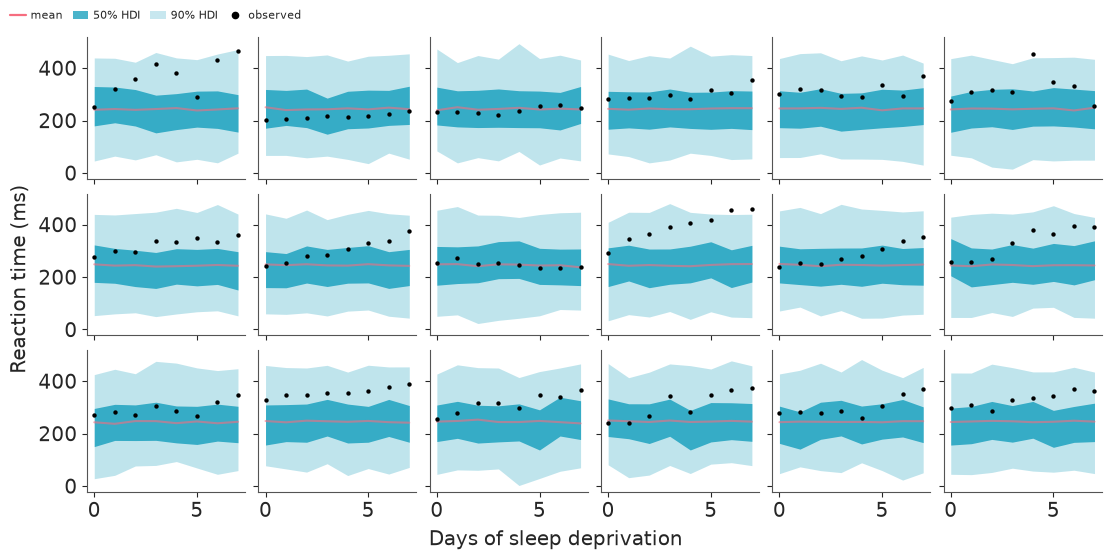

In [6]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 2.2 Data versus prior

How far does the posterior move away from a tight slope prior centered at zero?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.90,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(idata, var_names=["intercept", "slope", "sigma"], ci_prob=0.90, ci_kind="hdi", round_to=2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 7 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,299.98,5.58,290.60,308.92,2388.06,2629.75,1.0,0.11,0.08
slope,2.28,0.93,0.81,3.88,2240.48,2541.10,1.0,0.02,0.01
sigma,55.14,3.40,49.73,60.71,2757.50,2843.89,1.0,0.06,0.06


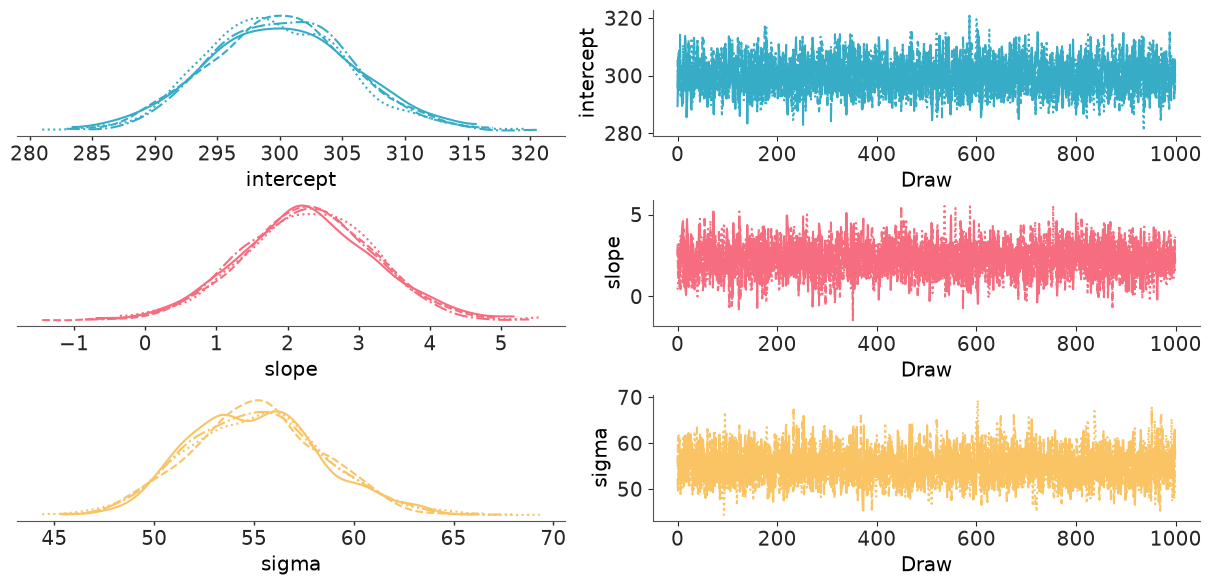

In [8]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma"]);

This plot shows posterior uncertainty in the population-average expected reaction time on each day. It does not include the variation of individual measurements.

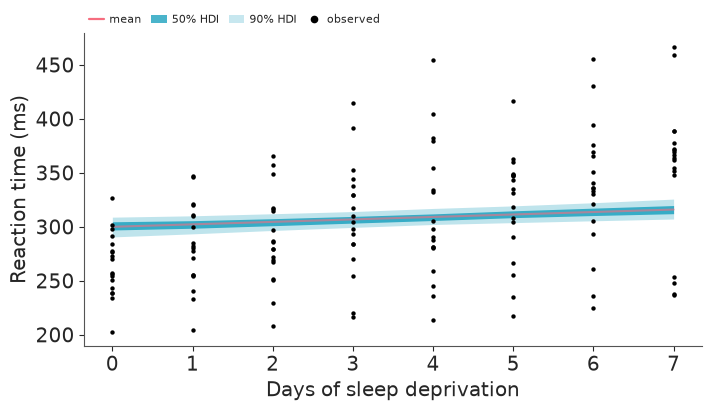

In [9]:
plot_population(idata, "mu")
plt.show()

## 2.3 Consequences of prior influence

Does the informative slope prior materially change the model’s predictions, or mainly its estimate of the deprivation slope?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

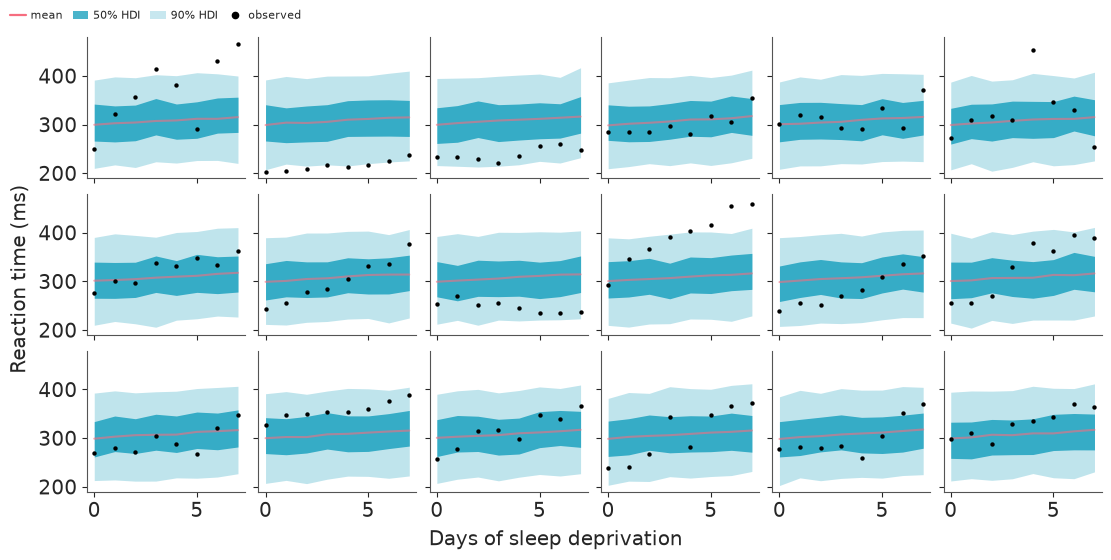

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The chapter uses power-scaling to ask whether modest changes in the prior would materially move the posterior.

In [11]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

azs.psense_summary(idata, var_names=["intercept", "slope", "sigma"])

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
intercept,0.189,0.236,potential prior-data conflict
slope,0.341,0.333,potential prior-data conflict
sigma,0.077,0.179,potential prior-data conflict


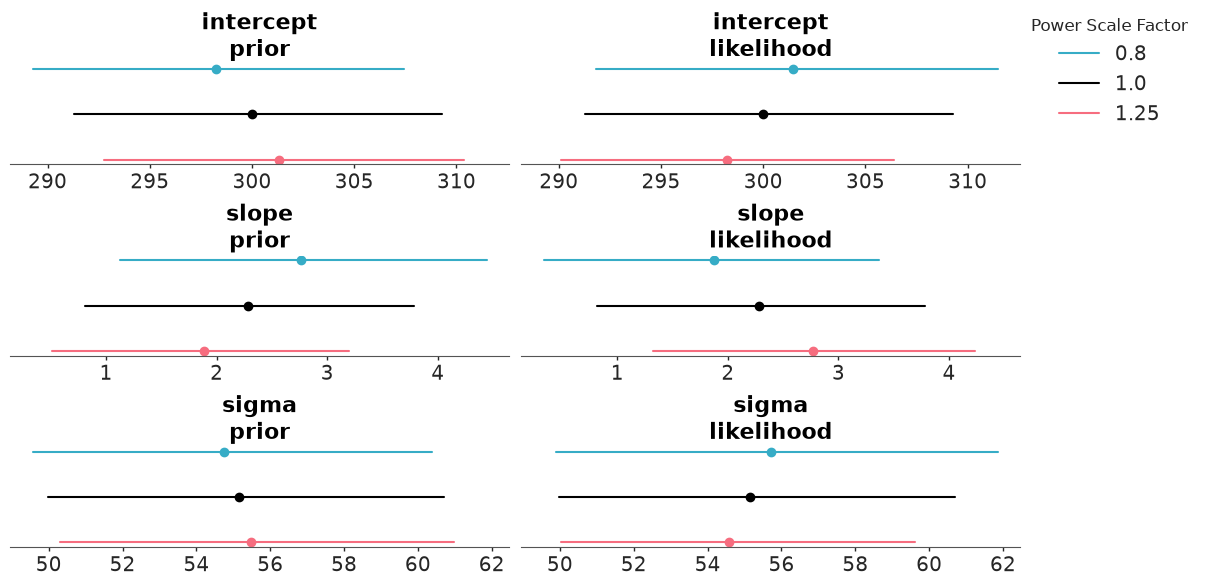

In [12]:
azp.plot_psense_dist(
    idata,
    var_names=["intercept", "slope", "sigma"],
    visuals={"dist": False},
);

## 2.4 Limits of prior tuning

Can changing the slope prior address the participant-to-participant structure visible in the data?

This is intentionally a prior experiment, not a preferred scientific model. With a simple model and substantial data, only a genuinely informative slope prior should visibly pull the posterior — compare the `slope` estimate here with notebook 1's, and check the sensitivity plot above to see how much of that pull the data can still overcome.